In [1]:
import numpy as np

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [2]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [3]:
class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.
    """

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        self._forward_inputs = [input]
        out = input
        for module in self.modules:
            out = module.forward(out)
            self._forward_inputs.append(out)
        self.output = out
        return self.output

    def backward(self, input, gradOutput):
        grad = gradOutput
        for i in range(len(self.modules) - 1, -1, -1):
            grad = self.modules[i].backward(self._forward_inputs[i], grad)
        self.gradInput = grad
        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        self.training = False
        for module in self.modules:
            module.evaluate()


# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [4]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW = gradOutput.T @ input
        self.gradb = gradOutput.sum(axis=0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q


## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [5]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        self.output = np.exp(self.output)
        self.output = self.output / self.output.sum(axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        probs = self.output
        self.gradInput = probs * (gradOutput - np.sum(gradOutput * probs, axis=1, keepdims=True))
        return self.gradInput


    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [6]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        self.output = self.output - np.log(np.exp(self.output).sum(axis=1, keepdims=True))
        return self.output

    def updateGradInput(self, input, gradOutput):
        probs = np.exp(self.output)
        self.gradInput = gradOutput - probs * gradOutput.sum(axis=1, keepdims=True)
        return self.gradInput


    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [7]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        if self.moving_mean is None:
            self.moving_mean = np.zeros(input.shape[1], dtype=input.dtype)
            self.moving_variance = np.ones(input.shape[1], dtype=input.dtype)

        if self.training:
            self.batch_mean = input.mean(axis=0)
            self.batch_variance = input.var(axis=0)
            self.centered_input = input - self.batch_mean
            self.std_inv = 1.0 / np.sqrt(self.batch_variance + self.EPS)
            self.output = self.centered_input * self.std_inv

            self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * self.batch_mean
            unbiased_var = self.batch_variance * input.shape[0] / max(input.shape[0] - 1, 1)
            self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * unbiased_var
        else:
            self.output = (input - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)
        return self.output

    def updateGradInput(self, input, gradOutput):
        if not self.training:
            self.gradInput = gradOutput / np.sqrt(self.moving_variance + self.EPS)
            return self.gradInput

        n = input.shape[0]
        x_hat = self.centered_input * self.std_inv
        self.gradInput = (1.0 / n) * self.std_inv * (
            n * gradOutput - gradOutput.sum(axis=0) - x_hat * np.sum(gradOutput * x_hat, axis=0)
        )
        return self.gradInput


    def __repr__(self):
        return "BatchNormalization"

In [8]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta = np.sum(gradOutput, axis=0)
        self.gradGamma = np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

<>:3: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:3: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\Ilya\AppData\Local\Temp\ipykernel_15228\3092293347.py:3: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  Implements linear transform of input y = \gamma * x + \beta


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [9]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        if self.training:
            self.mask = (np.random.rand(*input.shape) >= self.p).astype(input.dtype) / (1.0 - self.p)
            self.output = input * self.mask
        else:
            self.mask = None
            self.output = input.copy()
        return  self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            self.gradInput = gradOutput * self.mask
        else:
            self.gradInput = gradOutput
        return self.gradInput


    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [10]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.use_bias = bias
        self.padding_mode = padding_mode

        kh, kw = self._pair(self.kernel_size)
        stdv = 1. / np.sqrt(self.in_channels * kh * kw)

        self.weight = np.random.uniform(
            -stdv, stdv, (self.out_channels, self.in_channels, kh, kw)
        )
        self.gradWeight = np.zeros_like(self.weight)

        if self.use_bias:
            self.bias = np.random.uniform(-stdv, stdv, self.out_channels)
            self.gradBias = np.zeros_like(self.bias)
        else:
            self.bias = None
            self.gradBias = None

    def _pair(self, x):
        return x if isinstance(x, tuple) else (x, x)

    def _same_padding(self, h, w, kh, kw, sh, sw):
        out_h = int(np.ceil(h / sh))
        out_w = int(np.ceil(w / sw))
        pad_h = max((out_h - 1) * sh + kh - h, 0)
        pad_w = max((out_w - 1) * sw + kw - w, 0)
        return (pad_h // 2, pad_h - pad_h // 2, pad_w // 2, pad_w - pad_w // 2)

    def _pad_input(self, x, pads):
        pt, pb, pl, pr = pads
        if self.padding_mode == 'zeros':
            return np.pad(x, ((0, 0), (0, 0), (pt, pb), (pl, pr)), mode='constant')
        raise ValueError(f"Unsupported padding_mode: {self.padding_mode}")

    def _init_params(self):
        if getattr(self, 'gradWeight', None) is None or self.gradWeight.shape != self.weight.shape:
            self.gradWeight = np.zeros_like(self.weight)
        if self.use_bias and (getattr(self, 'gradBias', None) is None or self.gradBias.shape != self.bias.shape):
            self.gradBias = np.zeros_like(self.bias)

    def _get_pads(self, input_shape):
        _, _, h, w = input_shape
        kh, kw = self._pair(self.kernel_size)
        sh, sw = self._pair(self.stride)

        if self.padding == 'same':
            return self._same_padding(h, w, kh, kw, sh, sw)
        if self.padding == 'valid':
            return (0, 0, 0, 0)
        raise ValueError("padding must be 'same' or 'valid'")

    def updateOutput(self, input):
        self._init_params()
        kh, kw = self._pair(self.kernel_size)
        sh, sw = self._pair(self.stride)

        self._pads = self._get_pads(input.shape)
        self.input_padded = self._pad_input(input, self._pads)

        N, C, H_pad, W_pad = self.input_padded.shape
        H_out = (H_pad - kh) // sh + 1
        W_out = (W_pad - kw) // sw + 1

        shape = (N, C, H_out, W_out, kh, kw)
        strides = (
            self.input_padded.strides[0],
            self.input_padded.strides[1],
            sh * self.input_padded.strides[2],
            sw * self.input_padded.strides[3],
            self.input_padded.strides[2],
            self.input_padded.strides[3],
        )
        windows = np.lib.stride_tricks.as_strided(self.input_padded, shape=shape, strides=strides)
        self.cols = windows.transpose(0, 2, 3, 1, 4, 5).reshape(-1, C * kh * kw)

        out = self.cols @ self.weight.reshape(self.out_channels, -1).T
        if self.use_bias:
            out = out + self.bias

        self.output = out.reshape(N, H_out, W_out, self.out_channels).transpose(0, 3, 1, 2)
        return self.output

    def updateGradInput(self, input, gradOutput):
        kh, kw = self._pair(self.kernel_size)
        sh, sw = self._pair(self.stride)
        N, C, H, W = input.shape

        grad2d = gradOutput.transpose(0, 2, 3, 1).reshape(-1, self.out_channels)
        w2d = self.weight.reshape(self.out_channels, -1)
        grad_cols = grad2d @ w2d

        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]
        grad_windows = grad_cols.reshape(N, H_out, W_out, C, kh, kw).transpose(0, 3, 1, 2, 4, 5)
        grad_padded = np.zeros_like(self.input_padded)

        h_idx = np.arange(H_out)[:, None] * sh + np.arange(kh)[None, :]
        w_idx = np.arange(W_out)[:, None] * sw + np.arange(kw)[None, :]

        np.add.at(
            grad_padded,
            (
                np.arange(N)[:, None, None, None, None, None],
                np.arange(C)[None, :, None, None, None, None],
                h_idx[None, None, :, None, :, None],
                w_idx[None, None, None, :, None, :],
            ),
            grad_windows,
        )

        pt, pb, pl, pr = self._pads
        self.gradInput = grad_padded[:, :, pt:pt + H, pl:pl + W]

        self.gradWeight = (grad2d.T @ self.cols).reshape(self.out_channels, self.in_channels, kh, kw)
        if self.use_bias:
            self.gradBias = grad2d.sum(axis=0)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        if getattr(self, 'gradWeight', None) is None or self.gradWeight.shape != self.weight.shape:
            self.updateGradInput(input, gradOutput)

    def zeroGradParameters(self):
        if hasattr(self, 'gradWeight'):
            self.gradWeight.fill(0)
        if self.use_bias and hasattr(self, 'gradBias'):
            self.gradBias.fill(0)

    def getParameters(self):
        return [self.weight, self.bias] if self.use_bias else [self.weight]

    def getGradParameters(self):
        return [self.gradWeight, self.gradBias] if self.use_bias else [self.gradWeight]

    def __repr__(self):
        return "Conv2d"


#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [11]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def _pair(self, x):
        return x if isinstance(x, tuple) else (x, x)

    def updateOutput(self, input):
        kH, kW = self._pair(self.kernel_size)
        sH, sW = self._pair(self.stride)
        pH, pW = self._pair(self.padding)

        self.input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (pH, pH), (pW, pW)),
            mode='constant',
            constant_values=-np.inf,
        )

        N, C, H_pad, W_pad = self.input_padded.shape
        H_out = (H_pad - kH) // sH + 1
        W_out = (W_pad - kW) // sW + 1

        shape = (N, C, H_out, W_out, kH, kW)
        strides = (
            self.input_padded.strides[0],
            self.input_padded.strides[1],
            sH * self.input_padded.strides[2],
            sW * self.input_padded.strides[3],
            self.input_padded.strides[2],
            self.input_padded.strides[3],
        )
        windows = np.lib.stride_tricks.as_strided(self.input_padded, shape=shape, strides=strides)
        flat = windows.reshape(N, C, H_out, W_out, -1)
        self.argmax = flat.argmax(axis=-1)
        self.output = flat.max(axis=-1)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        kH, kW = self._pair(self.kernel_size)
        sH, sW = self._pair(self.stride)
        pH, pW = self._pair(self.padding)

        N, C, H_out, W_out = gradOutput.shape
        grad_padded = np.zeros_like(self.input_padded)
        h_base = np.arange(H_out)[None, None, :, None] * sH
        w_base = np.arange(W_out)[None, None, None, :] * sW
        kh_idx = self.argmax // kW
        kw_idx = self.argmax % kW

        np.add.at(
            grad_padded,
            (
                np.arange(N)[:, None, None, None],
                np.arange(C)[None, :, None, None],
                h_base + kh_idx,
                w_base + kw_idx,
            ),
            gradOutput,
        )

        self.gradInput = grad_padded[:, :, pH:pH + input.shape[2], pW:pW + input.shape[3]]
        return self.gradInput


    def __repr__(self):
        return "MaxPool2d"

class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def _pair(self, x):
        return x if isinstance(x, tuple) else (x, x)

    def updateOutput(self, input):
        kH, kW = self._pair(self.kernel_size)
        sH, sW = self._pair(self.stride)
        pH, pW = self._pair(self.padding)

        self.input_padded = np.pad(input, ((0, 0), (0, 0), (pH, pH), (pW, pW)), mode='constant')
        N, C, H_pad, W_pad = self.input_padded.shape
        H_out = (H_pad - kH) // sH + 1
        W_out = (W_pad - kW) // sW + 1

        shape = (N, C, H_out, W_out, kH, kW)
        strides = (
            self.input_padded.strides[0],
            self.input_padded.strides[1],
            sH * self.input_padded.strides[2],
            sW * self.input_padded.strides[3],
            self.input_padded.strides[2],
            self.input_padded.strides[3],
        )
        windows = np.lib.stride_tricks.as_strided(self.input_padded, shape=shape, strides=strides)
        self.output = windows.mean(axis=(-1, -2))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        kH, kW = self._pair(self.kernel_size)
        sH, sW = self._pair(self.stride)
        pH, pW = self._pair(self.padding)

        N, C, H_out, W_out = gradOutput.shape
        grad_padded = np.zeros_like(self.input_padded)
        grad_share = gradOutput[:, :, :, :, None, None] / (kH * kW)

        h_idx = np.arange(H_out)[:, None] * sH + np.arange(kH)[None, :]
        w_idx = np.arange(W_out)[:, None] * sW + np.arange(kW)[None, :]

        np.add.at(
            grad_padded,
            (
                np.arange(N)[:, None, None, None, None, None],
                np.arange(C)[None, :, None, None, None, None],
                h_idx[None, None, :, None, :, None],
                w_idx[None, None, None, :, None, :],
            ),
            grad_share,
        )

        self.gradInput = grad_padded[:, :, pH:pH + input.shape[2], pW:pW + input.shape[3]]
        return self.gradInput


    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [12]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()

        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        ndim = input.ndim
        start = self.start_dim if self.start_dim >= 0 else self.start_dim + ndim
        end = self.end_dim if self.end_dim >= 0 else self.end_dim + ndim
        new_shape = input.shape[:start] + (-1,) + input.shape[end + 1:]
        self.output = input.reshape(new_shape)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(input.shape)
        return self.gradInput


    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [13]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [14]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        self.output = np.where(input > 0, input, self.slope * input)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * np.where(input > 0, 1.0, self.slope)
        return self.gradInput


    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [15]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * np.where(input > 0, 1.0, self.alpha * np.exp(input))
        return self.gradInput


    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [16]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        self.output = np.log1p(np.exp(-np.abs(input))) + np.maximum(input, 0)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        sigmoid = 1.0 / (1.0 + np.exp(-input))
        self.gradInput = gradOutput * sigmoid
        return self.gradInput


    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [17]:
class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        erf_term = np.vectorize(__import__('math').erf)(input / np.sqrt(2.0))
        self.cdf = 0.5 * (1.0 + erf_term)
        self.output = input * self.cdf
        return  self.output

    def updateGradInput(self, input, gradOutput):
        pdf = np.exp(-0.5 * input ** 2) / np.sqrt(2.0 * np.pi)
        self.gradInput = gradOutput * (self.cdf + input * pdf)
        return self.gradInput


    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [18]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [19]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [20]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)
        self.output = -np.sum(target * np.log(input_clamp)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)
        self.gradInput = -target / input_clamp / input.shape[0]
        return self.gradInput


    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [21]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = -np.sum(target * input) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput = -target / input.shape[0]
        return self.gradInput


    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.
6. Свитч лося (метрики) и оптимайзера. - ЭТО ВЫ УДАЛИЛИ НА СЕМИНАРЕ!

# Часть 2. Мультирегрессия на своих модулях

В этом блоке реализуется решение для задачи мультирегрессии:

- датасет генерируется синтетически;
- модель строится **только** на кастомных слоях (`Sequential`, `Linear`, `BatchNormalization`, `Dropout`, активации);
- лосс — `MSECriterion`;
- оптимайзер — кастомный `AdamW` или `SGD`;
- есть `scheduler`, `warmup`, `early stopping`, сохранение лучшей модели;
- строятся графики loss и метрик на train/val;
- сравниваются `small`, `medium`, `large` модели.


In [22]:
import copy
import math
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from IPython.display import clear_output

## Кастомные оптимайзеры

Ниже — базовый `Optimizer`, а также `SGD` и `AdamW`.  
Они работают либо через `model=...`, либо через прямую передачу списков `params/grads`.


In [23]:
class Optimizer:
    """
    Базовый класс оптимайзера.
    Умеет работать с:
      1) моделью (у которой есть getParameters / getGradParameters / zeroGradParameters)
      2) или напрямую со списками params / grads.
    """
    def __init__(self, model=None, params=None, grads=None):
        self.model = model
        self._params_source = params
        self._grads_source = grads

        if model is None and (params is None or grads is None):
            raise ValueError("Pass either `model` or both `params` and `grads`.")

        self.params = self._current_params()
        self.grads = self._current_grads()

        if len(self.params) != len(self.grads):
            raise ValueError("Number of parameters and gradients must match.")

    def _flatten(self, obj):
        flat = []
        if isinstance(obj, (list, tuple)):
            for item in obj:
                flat.extend(self._flatten(item))
        elif obj is None:
            pass
        else:
            flat.append(obj)
        return flat

    def _current_params(self):
        source = self.model.getParameters() if self.model is not None else self._params_source
        return self._flatten(source)

    def _current_grads(self):
        source = self.model.getGradParameters() if self.model is not None else self._grads_source
        return self._flatten(source)

    def refresh(self):
        self.params = self._current_params()
        self.grads = self._current_grads()

        if len(self.params) != len(self.grads):
            raise ValueError("Number of parameters and gradients must match.")

    def zero_grad(self):
        if self.model is not None and hasattr(self.model, "zeroGradParameters"):
            self.model.zeroGradParameters()
        else:
            for grad in self._current_grads():
                grad.fill(0)

    def step(self):
        raise NotImplementedError

    def set_lr(self, lr):
        self.lr = lr

    def __repr__(self):
        return "Optimizer"


class SGD(Optimizer):
    """
    SGD с опциональным momentum и weight decay.
    """
    def __init__(self, model=None, params=None, grads=None, lr=1e-2, momentum=0.0, weight_decay=0.0):
        super(SGD, self).__init__(model=model, params=params, grads=grads)

        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.velocity = [np.zeros_like(param) for param in self.params]

    def step(self):
        self.refresh()

        if len(self.velocity) != len(self.params):
            self.velocity = [np.zeros_like(param) for param in self.params]

        for i, (param, grad) in enumerate(zip(self.params, self.grads)):
            update = grad

            if self.weight_decay != 0.0:
                update = update + self.weight_decay * param

            if self.momentum != 0.0:
                self.velocity[i] = self.momentum * self.velocity[i] - self.lr * update
                param += self.velocity[i]
            else:
                param -= self.lr * update

    def __repr__(self):
        return f"SGD(lr={self.lr}, momentum={self.momentum}, weight_decay={self.weight_decay})"


class AdamW(Optimizer):
    """
    AdamW: Adam + decoupled weight decay.
    """
    def __init__(self, model=None, params=None, grads=None, lr=1e-3,
                 betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-2):
        super(AdamW, self).__init__(model=model, params=params, grads=grads)

        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay

        self.m = [np.zeros_like(param) for param in self.params]
        self.v = [np.zeros_like(param) for param in self.params]
        self.t = 0

    def step(self):
        self.refresh()
        self.t += 1

        if len(self.m) != len(self.params):
            self.m = [np.zeros_like(param) for param in self.params]
            self.v = [np.zeros_like(param) for param in self.params]

        for i, (param, grad) in enumerate(zip(self.params, self.grads)):
            if self.weight_decay != 0.0:
                param *= (1.0 - self.lr * self.weight_decay)

            self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (grad * grad)

            m_hat = self.m[i] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)

            param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def __repr__(self):
        return (
            f"AdamW(lr={self.lr}, betas=({self.beta1}, {self.beta2}), "
            f"eps={self.eps}, weight_decay={self.weight_decay})"
        )

## Датасет для мультирегрессии

Используется синтетический датасет с 3 непрерывными целевыми переменными.  
Это удобно, потому что можно задать нелинейные зависимости между признаками и таргетами и быстро обучать несколько моделей.


In [25]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


class NumpyRegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# sklearn dataset for multi-regression
X, Y = make_regression(
    n_samples=14000,
    n_features=32,
    n_informative=24,
    n_targets=3,
    noise=10.0,
    random_state=42
)

X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train).astype(np.float32)
X_val   = x_scaler.transform(X_val).astype(np.float32)
X_test  = x_scaler.transform(X_test).astype(np.float32)

y_train = y_scaler.fit_transform(y_train).astype(np.float32)
y_val   = y_scaler.transform(y_val).astype(np.float32)
y_test  = y_scaler.transform(y_test).astype(np.float32)

batch_size = 128

train_loader = DataLoader(
    NumpyRegressionDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    NumpyRegressionDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    NumpyRegressionDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (10115, 32) (10115, 3)
Val:   (1785, 32) (1785, 3)
Test:  (2100, 32) (2100, 3)


## Архитектуры MLP на кастомных модулях

Все модели реализованы только на своих слоях.  
По просьбе архитектуры сделаны более ёмкими по числу параметров, особенно `medium` и `large`.

- `small`: компактная базовая MLP;
- `medium`: уже близка к шаблону `512 → 256 → 128 → 64`;
- `large`: ещё более широкая и глубокая сеть.


In [55]:
def get_activation(name):
    name = name.lower()
    if name == "relu":
        return ReLU()
    if name == "leakyrelu":
        return LeakyReLU(alpha=0.1)
    if name == "elu":
        return ELU(alpha=1.0)
    if name == "softplus":
        return SoftPlus()
    if name == "gelu":
        return Gelu()
    raise ValueError(f"Unknown activation: {name}")


def add_mlp_block(model, in_dim, out_dim, activation="relu", use_bn=True, dropout_p=None, bn_alpha=0.9):
    model.add(Linear(in_dim, out_dim))
    if use_bn:
        model.add(BatchNormalization(alpha=bn_alpha))
    model.add(get_activation(activation))
    if dropout_p is not None and dropout_p > 0:
        model.add(Dropout(p=dropout_p))


def build_regression_mlp(input_dim, output_dim, hidden_dims, activation="relu",
                         p_large=0.30, p_small=0.20, bn_alpha=0.9):
    model = Sequential()

    for i, hidden_dim in enumerate(hidden_dims):
        in_dim = input_dim if i == 0 else hidden_dims[i - 1]
        dropout_p = p_large if i < 2 else p_small
        add_mlp_block(
            model=model,
            in_dim=in_dim,
            out_dim=hidden_dim,
            activation=activation,
            use_bn=True,
            dropout_p=dropout_p,
            bn_alpha=bn_alpha
        )

    model.add(Linear(hidden_dims[-1], output_dim))
    return model


INPUT_DIM = X_train.shape[1]
OUTPUT_DIM = y_train.shape[1]

model_configs = {
    "small": {
        "hidden_dims": [256, 128, 64],
        "activation": "relu",
        "p_large": 0.20,
        "p_small": 0.10,
    },
    "medium": {
        "hidden_dims": [512, 256, 128, 64],
        "activation": "relu",
        "p_large": 0.25,
        "p_small": 0.15,
    },
    "large": {
        "hidden_dims": [1024, 512, 256, 128, 64],
        "activation": "relu",
        "p_large": 0.30,
        "p_small": 0.20,
    },
}

In [56]:
def count_parameters(model):
    flat_params = Optimizer(model=model)._flatten(model.getParameters())
    total_params = sum(p.size for p in flat_params)
    trainable_params = total_params
    return total_params, trainable_params


for model_name, cfg in model_configs.items():
    model = build_regression_mlp(
        input_dim=INPUT_DIM,
        output_dim=OUTPUT_DIM,
        hidden_dims=cfg["hidden_dims"],
        activation=cfg["activation"],
        p_large=cfg["p_large"],
        p_small=cfg["p_small"],
    )
    total_params, trainable_params = count_parameters(model)
    print(f"{model_name}: total={total_params}, trainable={trainable_params}")

small: total=49795, trainable=49795
medium: total=189571, trainable=189571
large: total=731267, trainable=731267


## Вспомогательные функции: метрики, сохранение весов, графики

In [57]:
def get_model_state(model):
    params = Optimizer(model=model)._flatten(model.getParameters())
    return [p.copy() for p in params]


def load_model_state(model, state):
    params = Optimizer(model=model)._flatten(model.getParameters())
    if len(params) != len(state):
        raise ValueError("State and model parameters have different lengths.")
    for param, saved in zip(params, state):
        param[...] = saved


def compute_regression_metrics(y_true_scaled, y_pred_scaled, y_scaler):
    y_true = y_scaler.inverse_transform(y_true_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred, multioutput="uniform_average")

    return {"rmse": rmse, "mae": mae, "r2": r2}


def plot_training_history(history):
    clear_output(wait=True)

    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(16, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MSE loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, history["train_rmse"], label="train_rmse")
    plt.plot(epochs, history["val_rmse"], label="val_rmse")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("RMSE")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(epochs, history["train_mae"], label="train_mae")
    plt.plot(epochs, history["val_mae"], label="val_mae")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("MAE")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, history["train_r2"], label="train_r2")
    plt.plot(epochs, history["val_r2"], label="val_r2")
    plt.xlabel("Epoch")
    plt.ylabel("R2")
    plt.title("R2")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Функции `train()` и `evaluate()`

Здесь реализованы:

- обучение по эпохам;
- вывод loss и метрик на train/val;
- `warmup`;
- `scheduler`;
- `early stopping`;
- восстановление лучшей модели после обучения.


In [58]:
def evaluate(model, criterion, data_loader, y_scaler):
    model.evaluate()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for batch_x, batch_y in data_loader:
        x_np = batch_x.numpy()
        y_np = batch_y.numpy()

        preds = model.forward(x_np)
        loss = criterion.forward(preds, y_np)

        total_loss += loss * len(x_np)
        all_preds.append(preds.copy())
        all_targets.append(y_np.copy())

    avg_loss = total_loss / len(data_loader.dataset)

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    metrics = compute_regression_metrics(all_targets, all_preds, y_scaler)

    return {
        "loss": avg_loss,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r2": metrics["r2"],
    }


def train(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    y_scaler,
    epochs=40,
    warmup_epochs=5,
    early_stopping_patience=8,
    min_delta=1e-4,
    verbose=True,
    draw_plots=True
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_rmse": [],
        "val_rmse": [],
        "train_mae": [],
        "val_mae": [],
        "train_r2": [],
        "val_r2": [],
        "lr": []
    }

    dummy_param = torch.nn.Parameter(torch.tensor(0.0))
    torch_optimizer = torch.optim.Adam([dummy_param], lr=optimizer.lr)

    steps_per_epoch = len(train_loader)
    total_steps = max(1, epochs * steps_per_epoch)
    warmup_steps = max(1, warmup_epochs * steps_per_epoch)

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(torch_optimizer, lr_lambda=lr_lambda)

    best_state = get_model_state(model)
    best_val_loss = float("inf")
    best_epoch = 0
    bad_epochs = 0

    global_step = 0

    for epoch in range(1, epochs + 1):
        model.train()

        total_train_loss = 0.0
        train_preds = []
        train_targets = []

        start_time = time.time()

        for batch_x, batch_y in train_loader:
            x_np = batch_x.numpy()
            y_np = batch_y.numpy()

            current_lr = torch_optimizer.param_groups[0]["lr"]
            optimizer.set_lr(current_lr)
            optimizer.zero_grad()

            preds = model.forward(x_np)
            loss = criterion.forward(preds, y_np)

            grad_output = criterion.backward(preds, y_np)
            model.backward(x_np, grad_output)
            optimizer.step()

            scheduler.step()
            global_step += 1

            total_train_loss += loss * len(x_np)
            train_preds.append(preds.copy())
            train_targets.append(y_np.copy())

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_preds = np.vstack(train_preds)
        train_targets = np.vstack(train_targets)
        train_metrics = compute_regression_metrics(train_targets, train_preds, y_scaler)

        val_stats = evaluate(model, criterion, val_loader, y_scaler)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_stats["loss"])
        history["train_rmse"].append(train_metrics["rmse"])
        history["val_rmse"].append(val_stats["rmse"])
        history["train_mae"].append(train_metrics["mae"])
        history["val_mae"].append(val_stats["mae"])
        history["train_r2"].append(train_metrics["r2"])
        history["val_r2"].append(val_stats["r2"])
        history["lr"].append(current_lr)

        elapsed = time.time() - start_time

        if verbose:
            print(
                f"Epoch [{epoch:03d}/{epochs:03d}] | "
                f"lr={current_lr:.6f} | "
                f"train_loss={avg_train_loss:.6f} | val_loss={val_stats['loss']:.6f} | "
                f"train_rmse={train_metrics['rmse']:.6f} | val_rmse={val_stats['rmse']:.6f} | "
                f"train_mae={train_metrics['mae']:.6f} | val_mae={val_stats['mae']:.6f} | "
                f"train_r2={train_metrics['r2']:.6f} | val_r2={val_stats['r2']:.6f} | "
                f"time={elapsed:.2f}s"
            )

        if draw_plots:
            plot_training_history(history)

        if val_stats["loss"] < best_val_loss - min_delta:
            best_val_loss = val_stats["loss"]
            best_state = get_model_state(model)
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    load_model_state(model, best_state)

    return model, history, best_epoch, best_val_loss

In [59]:
def plot_single_model_history(history, model_name):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(16, 10))
    plt.suptitle(f"Training history: {model_name}", fontsize=16)

    plt.subplot(2, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MSE loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, history["train_rmse"], label="train_rmse")
    plt.plot(epochs, history["val_rmse"], label="val_rmse")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("RMSE")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(epochs, history["train_mae"], label="train_mae")
    plt.plot(epochs, history["val_mae"], label="val_mae")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("MAE")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, history["train_r2"], label="train_r2")
    plt.plot(epochs, history["val_r2"], label="val_r2")
    plt.xlabel("Epoch")
    plt.ylabel("R2")
    plt.title("R2")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Обучение трёх моделей и сравнение результатов

In [60]:
results = {}

for model_name, cfg in model_configs.items():
    print("=" * 90)
    print(f"Training: {model_name}")
    print("=" * 90)

    model = build_regression_mlp(
        input_dim=INPUT_DIM,
        output_dim=OUTPUT_DIM,
        hidden_dims=cfg["hidden_dims"],
        activation=cfg["activation"],
        p_large=cfg["p_large"],
        p_small=cfg["p_small"],
    )

    total_params, trainable_params = count_parameters(model)
    print(f"Parameters -> total: {total_params}, trainable: {trainable_params}")
    print(model)

    criterion = MSECriterion()
    optimizer = AdamW(model=model, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-4)

    best_model, history, best_epoch, best_val_loss = train(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        y_scaler=y_scaler,
        epochs=30,
        warmup_epochs=5,
        early_stopping_patience=8,
        min_delta=1e-4,
        verbose=True,
        draw_plots=False
    )

    test_stats = evaluate(best_model, criterion, test_loader, y_scaler)

    results[model_name] = {
        "model": best_model,
        "history": history,
        "params_total": total_params,
        "params_trainable": trainable_params,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_loss": test_stats["loss"],
        "test_rmse": test_stats["rmse"],
        "test_mae": test_stats["mae"],
        "test_r2": test_stats["r2"],
    }

    print("\nTest metrics:")
    print(f"loss: {test_stats['loss']:.6f}")
    print(f"rmse: {test_stats['rmse']:.6f}")
    print(f"mae:  {test_stats['mae']:.6f}")
    print(f"r2:   {test_stats['r2']:.6f}")

Training: small
Parameters -> total: 49795, trainable: 49795
Linear 32 -> 256
BatchNormalization
ReLU
Dropout
Linear 256 -> 128
BatchNormalization
ReLU
Dropout
Linear 128 -> 64
BatchNormalization
ReLU
Dropout
Linear 64 -> 3



C:\Users\Ilya\AppData\Local\Temp\ipykernel_19084\616910978.py:105: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch [001/030] | lr=0.000200 | train_loss=2.618358 | val_loss=1.100531 | train_rmse=255.976479 | val_rmse=166.447261 | train_mae=200.826310 | val_mae=131.002533 | train_r2=0.127214 | val_r2=0.619754 | time=0.63s
Epoch [002/030] | lr=0.000400 | train_loss=0.805770 | val_loss=0.202339 | train_rmse=141.697275 | val_rmse=70.396958 | train_mae=109.664693 | val_mae=55.951200 | train_r2=0.731410 | val_r2=0.929961 | time=0.63s
Epoch [003/030] | lr=0.000600 | train_loss=0.425290 | val_loss=0.106978 | train_rmse=102.763258 | val_rmse=51.508352 | train_mae=80.512164 | val_mae=40.873872 | train_r2=0.858237 | val_r2=0.963000 | time=0.60s
Epoch [004/030] | lr=0.000800 | train_loss=0.330353 | val_loss=0.081046 | train_rmse=90.604621 | val_rmse=44.776977 | train_mae=70.784523 | val_mae=35.697943 | train_r2=0.889882 | val_r2=0.971964 | time=0.60s
Epoch [005/030] | lr=0.001000 | train_loss=0.267210 | val_loss=0.071425 | train_rmse=81.618326 | val_rmse=42.369468 | train_mae=63.817438 | val_mae=33.296896

C:\Users\Ilya\AppData\Local\Temp\ipykernel_19084\616910978.py:105: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch [001/030] | lr=0.000200 | train_loss=2.694145 | val_loss=0.826348 | train_rmse=259.306642 | val_rmse=145.624889 | train_mae=203.569610 | val_mae=114.125736 | train_r2=0.101952 | val_r2=0.714865 | time=1.51s
Epoch [002/030] | lr=0.000400 | train_loss=0.747063 | val_loss=0.130327 | train_rmse=136.403555 | val_rmse=57.200945 | train_mae=106.392551 | val_mae=44.975329 | train_r2=0.750979 | val_r2=0.954962 | time=1.43s
Epoch [003/030] | lr=0.000600 | train_loss=0.434440 | val_loss=0.098350 | train_rmse=103.774359 | val_rmse=49.796889 | train_mae=81.083216 | val_mae=39.076048 | train_r2=0.855187 | val_r2=0.966023 | time=1.45s
Epoch [004/030] | lr=0.000800 | train_loss=0.335071 | val_loss=0.059540 | train_rmse=91.175424 | val_rmse=38.273830 | train_mae=71.292364 | val_mae=30.099235 | train_r2=0.888310 | val_r2=0.979396 | time=1.48s
Epoch [005/030] | lr=0.001000 | train_loss=0.285000 | val_loss=0.057708 | train_rmse=84.007095 | val_rmse=37.767448 | train_mae=65.122619 | val_mae=30.288169

C:\Users\Ilya\AppData\Local\Temp\ipykernel_19084\616910978.py:105: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch [001/030] | lr=0.000200 | train_loss=2.680397 | val_loss=0.575583 | train_rmse=259.858091 | val_rmse=120.492549 | train_mae=202.170886 | val_mae=94.485094 | train_r2=0.106534 | val_r2=0.801153 | time=4.89s
Epoch [002/030] | lr=0.000400 | train_loss=0.768690 | val_loss=0.211286 | train_rmse=138.555884 | val_rmse=73.569433 | train_mae=107.750230 | val_mae=58.067925 | train_r2=0.743770 | val_r2=0.927086 | time=4.23s
Epoch [003/030] | lr=0.000600 | train_loss=0.492075 | val_loss=0.077502 | train_rmse=110.919132 | val_rmse=43.231556 | train_mae=86.065415 | val_mae=33.941869 | train_r2=0.835975 | val_r2=0.973145 | time=4.27s
Epoch [004/030] | lr=0.000800 | train_loss=0.380862 | val_loss=0.125103 | train_rmse=97.684848 | val_rmse=56.286125 | train_mae=75.812038 | val_mae=43.698913 | train_r2=0.873046 | val_r2=0.956792 | time=4.33s
Epoch [005/030] | lr=0.001000 | train_loss=0.320444 | val_loss=0.111932 | train_rmse=89.448546 | val_rmse=52.591023 | train_mae=69.006891 | val_mae=41.907398 

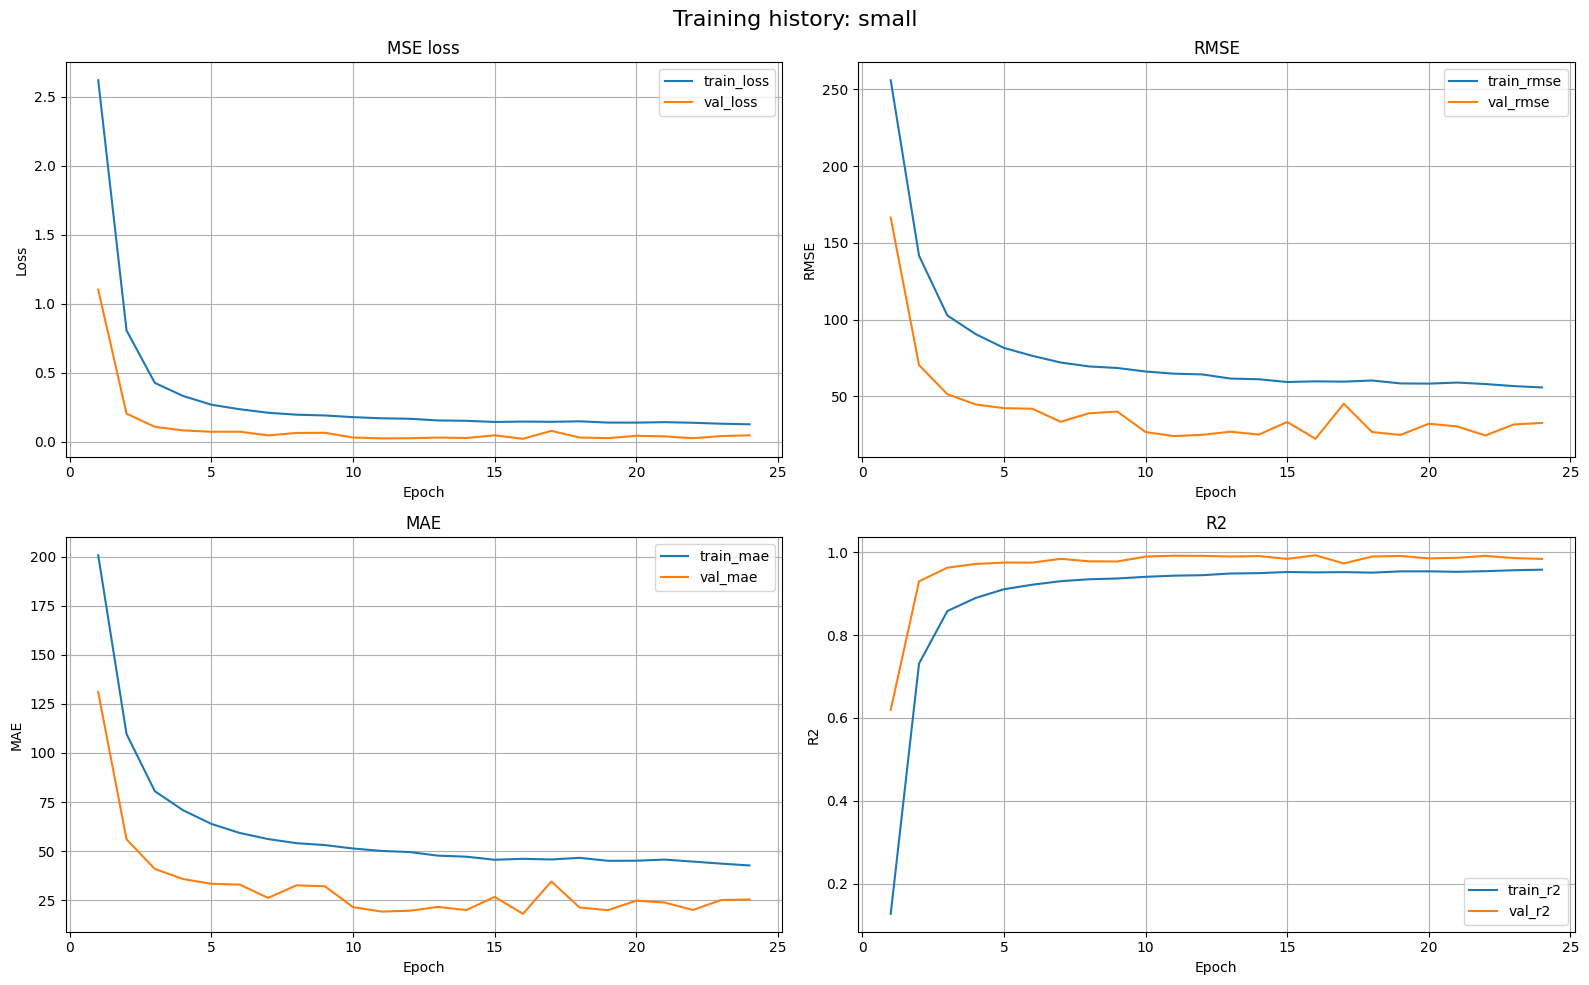

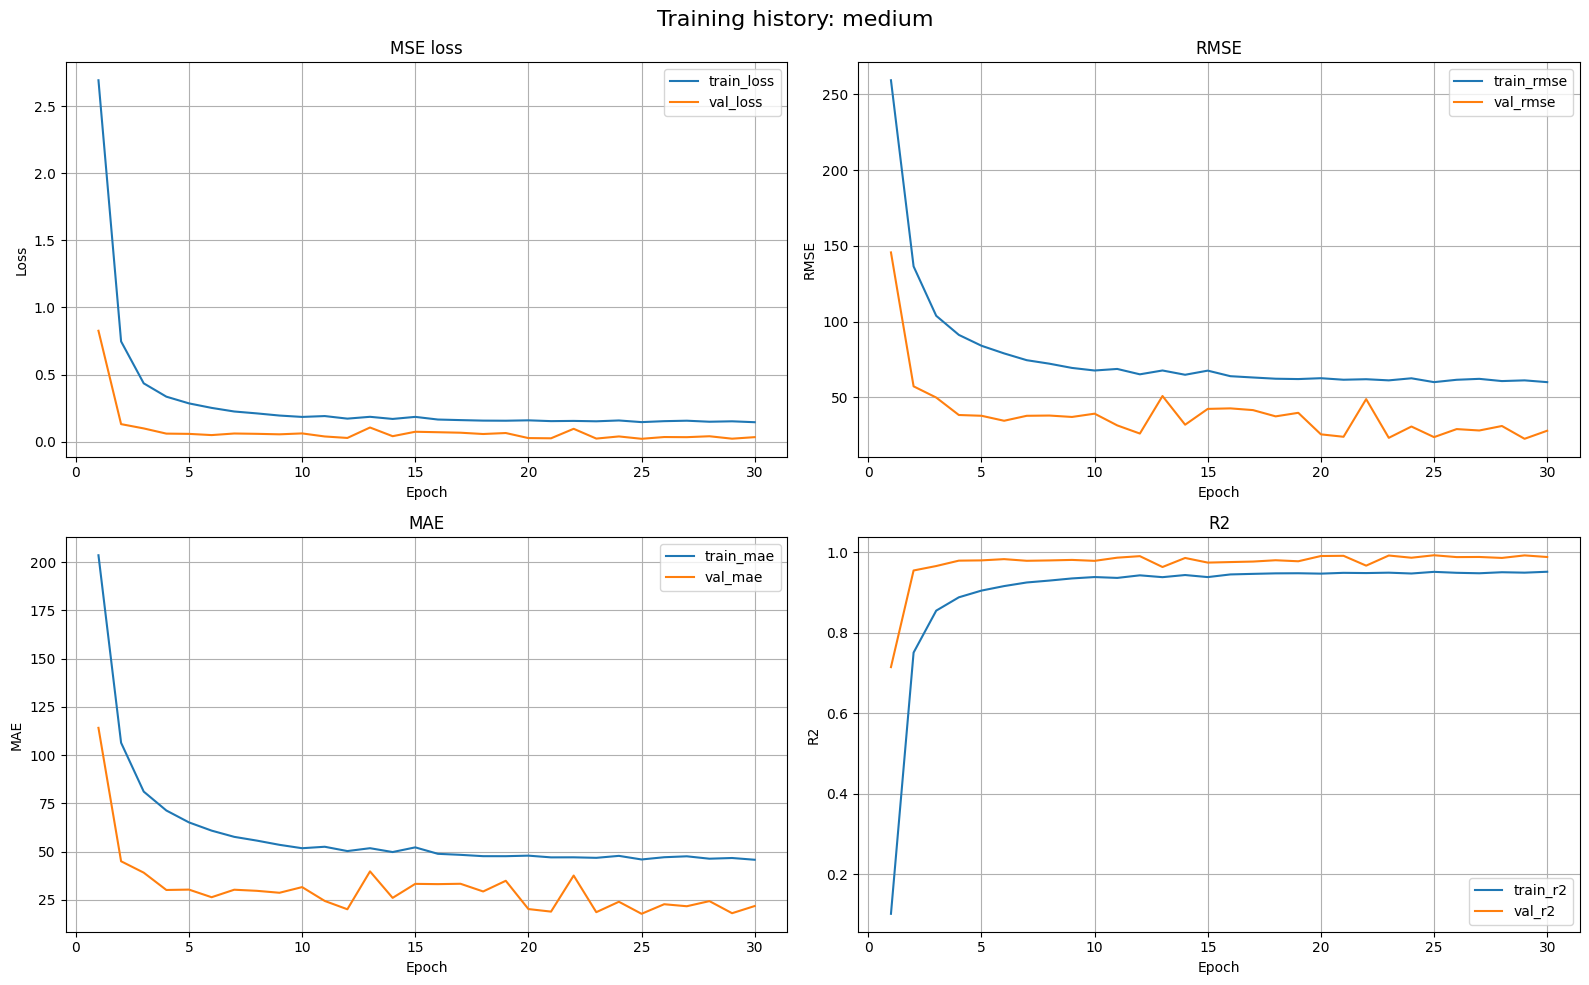

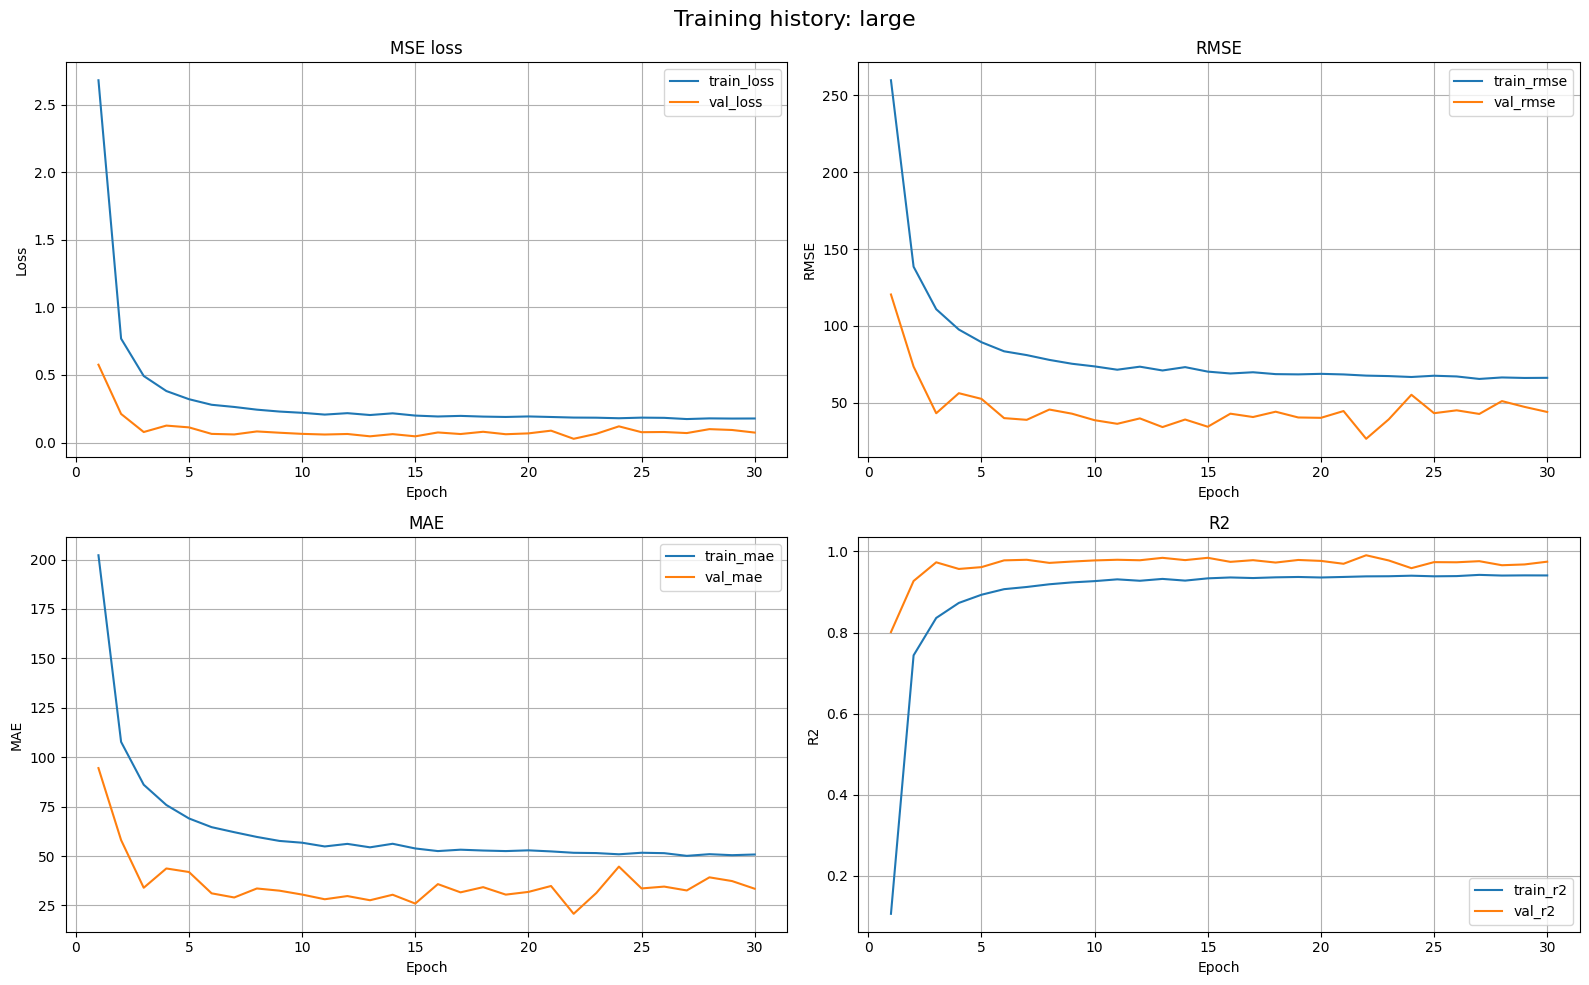

In [61]:
for model_name, info in results.items():
    plot_single_model_history(info["history"], model_name)

In [62]:
print("Final comparison:")
for model_name, info in results.items():
    print(
        f"{model_name:>6} | "
        f"params={info['params_total']:>9} | "
        f"best_epoch={info['best_epoch']:>3} | "
        f"test_loss={info['test_loss']:.6f} | "
        f"test_rmse={info['test_rmse']:.6f} | "
        f"test_mae={info['test_mae']:.6f} | "
        f"test_r2={info['test_r2']:.6f}"
    )

Final comparison:
 small | params=    49795 | best_epoch= 16 | test_loss=0.131695 | test_rmse=56.391580 | test_mae=44.004549 | test_r2=0.953525
medium | params=   189571 | best_epoch= 25 | test_loss=0.033884 | test_rmse=28.242482 | test_mae=22.107210 | test_r2=0.988020
 large | params=   731267 | best_epoch= 22 | test_loss=0.109309 | test_rmse=53.426556 | test_mae=40.644843 | test_r2=0.961836


# Часть 2. Мультиклассификация на MNIST на своих модулях

Ниже реализована сверточная модель для классификации цифр MNIST.  
**Важно:** `Dataset` и `DataLoader` берутся из `torch/torchvision`, а сама сеть, функция потерь и оптимизатор — **только на моих собственных модулях**.

Что здесь выполнено:
1. выбрана корректная функция потерь и метрика;
2. есть графики loss и accuracy на train/validation;
3. встроен scheduler для learning rate;
4. встроен warmup;
5. реализованы early stopping и сохранение лучшей модели.


In [26]:
import os
import time
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

## Подготовка данных MNIST

Используем стандартный датасет `MNIST` из `torchvision`.  
Изображения нормализуем и затем переводим батчи в `numpy`, потому что моя модель и мои слои работают именно с `numpy`-массивами.


In [27]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 256
NUM_WORKERS = 0

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_size = 55000
val_size = len(mnist_train_full) - train_size

mnist_train, mnist_val = random_split(
    mnist_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(mnist_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train size: {len(mnist_train)}")
print(f"Val size:   {len(mnist_val)}")
print(f"Test size:  {len(mnist_test)}")

Train size: 55000
Val size:   5000
Test size:  10000


## Архитектура сверточной сети

Архитектура строится **только из собственных модулей**:
- `Conv2d`
- `ReLU`
- `MaxPool2d`
- `Flatten`
- `Linear`
- `LogSoftMax`

На выходе используется `LogSoftMax`, потому что дальше применяется `ClassNLLCriterion`.  
Это стандартная и корректная связка для задачи многоклассовой классификации.


In [27]:
def build_mnist_cnn():
    model = Sequential()

    model.add(Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding='same', bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding='same', bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten(start_dim=1))
    model.add(Linear(32 * 7 * 7, 128))
    model.add(ReLU())
    model.add(Dropout(p=0.20))
    model.add(Linear(128, 10))
    model.add(LogSoftMax())

    return model

mnist_model = build_mnist_cnn()
print(mnist_model)

Conv2d
ReLU
MaxPool2d
Conv2d
ReLU
MaxPool2d
Flatten
Linear 1568 -> 128
ReLU
Dropout
Linear 128 -> 10
LogSoftMax



## Вспомогательные функции

Здесь определяются:
- one-hot кодирование целевых меток;
- accuracy;
- сохранение и восстановление лучшего состояния модели;
- функция оценки на валидации и тесте.


In [36]:
def to_one_hot(y, num_classes=10):
    y = np.asarray(y, dtype=np.int64).reshape(-1)
    one_hot = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    one_hot[np.arange(y.shape[0]), y] = 1.0
    return one_hot


def predict_classes_from_log_probs(log_probs):
    return np.argmax(log_probs, axis=1)


def classification_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(y_true == y_pred))


def get_model_state(model):
    params = Optimizer(model=model)._flatten(model.getParameters())
    return [p.copy() for p in params]


def load_model_state(model, state):
    params = Optimizer(model=model)._flatten(model.getParameters())
    if len(params) != len(state):
        raise ValueError("State and model parameters have different lengths.")
    for param, saved in zip(params, state):
        param[...] = saved


def evaluate_classification(model, criterion, data_loader):
    model.evaluate()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for batch_x, batch_y in data_loader:
        x_np = batch_x.numpy().astype(np.float32)
        y_np = batch_y.numpy().astype(np.int64)
        y_one_hot = to_one_hot(y_np, num_classes=10)

        log_probs = model.forward(x_np)
        loss = criterion.forward(log_probs, y_one_hot)

        total_loss += loss * len(x_np)
        all_preds.append(predict_classes_from_log_probs(log_probs))
        all_targets.append(y_np)

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    acc = classification_accuracy(all_targets, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc,
    }

## Обучение: optimizer, scheduler, warmup, early stopping

Для обновления весов используется **мой `AdamW`**.  
Для изменения learning rate используется стандартная схема:

- **linear warmup** в начале обучения;
- затем **cosine annealing**.

То есть сначала learning rate плавно растёт, чтобы стабилизировать старт обучения,  
а затем плавно уменьшается, чтобы аккуратно дообучить модель.

Также я добавил следующие ништяки:
- early stopping по `val_loss`;
- сохранение лучшего состояния модели;
- история по loss / accuracy / lr.


In [35]:
def train_mnist_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    epochs=12,
    warmup_epochs=2,
    early_stopping_patience=4,
    min_delta=1e-4,
    verbose=True,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": [],
    }

    best_state = get_model_state(model)
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0
    bad_epochs = 0

    steps_per_epoch = len(train_loader)

    dummy_param = torch.nn.Parameter(torch.tensor(0.0))
    scheduler_optimizer = torch.optim.SGD([dummy_param], lr=optimizer.lr)

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        scheduler_optimizer,
        start_factor=0.2,
        end_factor=1.0,
        total_iters=max(1, warmup_epochs * steps_per_epoch),
    )

    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        scheduler_optimizer,
        T_max=max(1, (epochs - warmup_epochs) * steps_per_epoch),
        eta_min=1e-4,
    )

    scheduler = torch.optim.lr_scheduler.SequentialLR(
        scheduler_optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[max(1, warmup_epochs * steps_per_epoch)],
    )

    for epoch in range(1, epochs + 1):
        print(f"Start epoch {epoch}/{epochs}")
        model.train()

        total_train_loss = 0.0
        train_preds = []
        train_targets = []

        start_time = time.time()

        for batch_x, batch_y in train_loader:
            x_np = batch_x.numpy().astype(np.float32)
            y_np = batch_y.numpy().astype(np.int64)
            y_one_hot = to_one_hot(y_np, num_classes=10)

            current_lr = scheduler_optimizer.param_groups[0]["lr"]
            optimizer.set_lr(current_lr)
            optimizer.zero_grad()

            log_probs = model.forward(x_np)
            loss = criterion.forward(log_probs, y_one_hot)

            grad_output = criterion.backward(log_probs, y_one_hot)
            model.backward(x_np, grad_output)

            optimizer.step()
            scheduler_optimizer.step()
            scheduler.step()

            total_train_loss += loss * len(x_np)
            train_preds.append(predict_classes_from_log_probs(log_probs))
            train_targets.append(y_np)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_preds = np.concatenate(train_preds)
        train_targets = np.concatenate(train_targets)
        train_acc = classification_accuracy(train_targets, train_preds)

        val_stats = evaluate_classification(model, criterion, val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_stats["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_stats["accuracy"])
        history["lr"].append(current_lr)

        elapsed = time.time() - start_time

        if verbose:
            print(
                f"Epoch [{epoch:02d}/{epochs:02d}] | "
                f"lr={current_lr:.6f} | "
                f"train_loss={avg_train_loss:.5f} | val_loss={val_stats['loss']:.5f} | "
                f"train_acc={train_acc:.4f} | val_acc={val_stats['accuracy']:.4f} | "
                f"time={elapsed:.1f}s"
            )

        improved = val_stats["loss"] < (best_val_loss - min_delta)

        if improved:
            best_val_loss = val_stats["loss"]
            best_val_acc = val_stats["accuracy"]
            best_epoch = epoch
            best_state = get_model_state(model)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    load_model_state(model, best_state)

    return history, {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "best_state": best_state,
    }

## Графики обучения

Ниже строятся:
- график функции потерь на train/validation;
- график accuracy на train/validation;
- график изменения learning rate.


In [36]:
def plot_mnist_history(history):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("NLL loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["lr"], label="lr")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("LR schedule")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Запуск обучения и проверка на тесте

Здесь:
- задаётся корректная функция потерь `ClassNLLCriterion`;
- используется мой оптимизатор `AdamW`;
- обучается лучшая версия модели;
- после обучения проверяется качество на test.


Start epoch 1/6
Epoch [01/06] | lr=0.001797 | train_loss=0.28619 | val_loss=0.08427 | train_acc=0.9132 | val_acc=0.9736 | time=169.9s
Start epoch 2/6
Epoch [02/06] | lr=0.002997 | train_loss=0.07483 | val_loss=0.05596 | train_acc=0.9770 | val_acc=0.9826 | time=168.2s
Start epoch 3/6
Epoch [03/06] | lr=0.002577 | train_loss=0.05335 | val_loss=0.04628 | train_acc=0.9835 | val_acc=0.9868 | time=165.3s
Start epoch 4/6
Epoch [04/06] | lr=0.001553 | train_loss=0.03357 | val_loss=0.03231 | train_acc=0.9897 | val_acc=0.9906 | time=174.2s
Start epoch 5/6
Epoch [05/06] | lr=0.000527 | train_loss=0.01966 | val_loss=0.02953 | train_acc=0.9933 | val_acc=0.9918 | time=166.6s
Start epoch 6/6
Epoch [06/06] | lr=0.000100 | train_loss=0.01072 | val_loss=0.02998 | train_acc=0.9972 | val_acc=0.9914 | time=243.9s


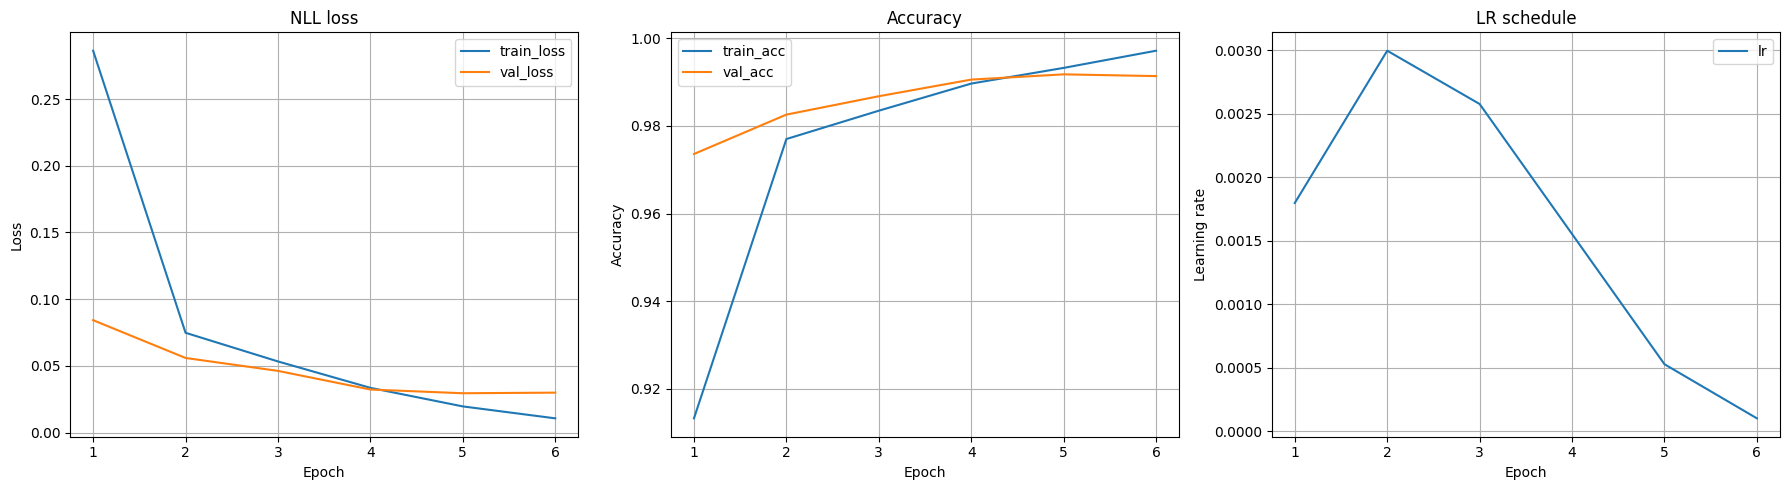


Best epoch: 5
Best val loss: 0.029530
Best val accuracy: 0.9918
Test loss: 0.022936
Test accuracy: 0.9921


In [39]:
mnist_model = build_mnist_cnn()
criterion_cls = ClassNLLCriterion()

optimizer_cls = AdamW(
    model=mnist_model,
    lr=0.003,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4,
)

history_mnist, best_info_mnist = train_mnist_model(
    model=mnist_model,
    criterion=criterion_cls,
    optimizer=optimizer_cls,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=6,
    warmup_epochs=2,
    early_stopping_patience=4,
    min_delta=1e-4,
    verbose=True,
)

plot_mnist_history(history_mnist)

test_stats = evaluate_classification(mnist_model, criterion_cls, test_loader)

print("\nBest epoch:", best_info_mnist["best_epoch"])
print(f"Best val loss: {best_info_mnist['best_val_loss']:.6f}")
print(f"Best val accuracy: {best_info_mnist['best_val_acc']:.4f}")
print(f"Test loss: {test_stats['loss']:.6f}")
print(f"Test accuracy: {test_stats['accuracy']:.4f}")

### __На торче бы обучалось гораздо быстрее__

### Но в принципе достаточно добротный результат

## Автоэнкодер для MNIST на собственных модулях

В завершающей части реализуется **денойзинг-автоэнкодер** для MNIST.  
Идея следующая:

- на вход подаётся изображение цифры, в которое специально добавляется шум;
- модель должна восстановить исходную чистую картинку;
- в энкодере используются **свёртки**, **max-pooling**, **flatten** и **полносвязные слои**;
- в bottleneck и decoder-части используются **Linear**, **BatchNormalization**, **Dropout** и нелинейности.


В качестве функции потерь берётся **MSE**, потому что задача автоэнкодера — восстановление изображения, то есть регрессия по пикселям.  
Дополнительно отслеживается **MAE**, чтобы удобнее интерпретировать качество реконструкции.


In [ ]:

from torch.utils.data import DataLoader, Subset

AE_BATCH_SIZE = 256
AE_NUM_WORKERS = 0

AE_USE_SUBSET = True
AE_TRAIN_LIMIT = 12000
AE_VAL_LIMIT = 2000
AE_TEST_LIMIT = 2000

def maybe_make_subset(dataset, limit, seed=42):
    if limit is None or limit >= len(dataset):
        return dataset
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(dataset))[:limit].tolist()
    return Subset(dataset, indices)

ae_train_dataset = maybe_make_subset(mnist_train, AE_TRAIN_LIMIT, seed=SEED) if AE_USE_SUBSET else mnist_train
ae_val_dataset = maybe_make_subset(mnist_val, AE_VAL_LIMIT, seed=SEED + 1) if AE_USE_SUBSET else mnist_val
ae_test_dataset = maybe_make_subset(mnist_test, AE_TEST_LIMIT, seed=SEED + 2) if AE_USE_SUBSET else mnist_test

ae_train_loader = DataLoader(ae_train_dataset, batch_size=AE_BATCH_SIZE, shuffle=True, num_workers=AE_NUM_WORKERS)
ae_val_loader = DataLoader(ae_val_dataset, batch_size=AE_BATCH_SIZE, shuffle=False, num_workers=AE_NUM_WORKERS)
ae_test_loader = DataLoader(ae_test_dataset, batch_size=AE_BATCH_SIZE, shuffle=False, num_workers=AE_NUM_WORKERS)

print(f"AE train size: {len(ae_train_dataset)}")
print(f"AE val size:   {len(ae_val_dataset)}")
print(f"AE test size:  {len(ae_test_dataset)}")


AE train size: 12000
AE val size:   2000
AE test size:  2000


## Архитектура автоэнкодера

Ниже сеть строится **только из уже реализованных модулей**.  
Отдельно ничего в базовых классах менять не требуется.

Схема такая:

1. **Encoder**:
   - `Conv2d(1 -> 8)` + `ReLU` + `MaxPool2d`
   - `Conv2d(8 -> 16)` + `ReLU` + `MaxPool2d`
   - `Flatten`
   - `Linear(16*7*7 -> 128)` + `BatchNormalization` + `ReLU` + `Dropout`
   - `Linear(128 -> latent_dim)`

2. **Decoder**:
   - `Linear(latent_dim -> 128)` + `BatchNormalization` + `ReLU` + `Dropout`
   - `Linear(128 -> 16*7*7)` + `ReLU`
   - `Linear(16*7*7 -> 28*28)`

На выходе получается вектор длины `784`, который затем можно вернуть к форме `1 x 28 x 28`.


In [29]:

def build_mnist_autoencoder(latent_dim=32, dropout_p=0.15, bn_alpha=0.9):
    model = Sequential()

    # encoder
    model.add(Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding='same', bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding='same', bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten(start_dim=1))
    model.add(Linear(16 * 7 * 7, 128))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=dropout_p))
    model.add(Linear(128, latent_dim))

    # decoder
    model.add(Linear(latent_dim, 128))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=dropout_p))
    model.add(Linear(128, 16 * 7 * 7))
    model.add(ReLU())
    model.add(Linear(16 * 7 * 7, 28 * 28))

    return model

autoencoder = build_mnist_autoencoder(latent_dim=32, dropout_p=0.15, bn_alpha=0.9)
print(autoencoder)


Conv2d
ReLU
MaxPool2d
Conv2d
ReLU
MaxPool2d
Flatten
Linear 784 -> 128
BatchNormalization
ReLU
Dropout
Linear 128 -> 32
Linear 32 -> 128
BatchNormalization
ReLU
Dropout
Linear 128 -> 784
ReLU
Linear 784 -> 784



## Вспомогательные функции для денойзинга и оценки

Так как MNIST в ноутбуке уже нормализован через

\[
x_{norm} = \frac{x - 0.1307}{0.3081},
\]

для автоэнкодера удобно сначала вернуть изображение в диапазон примерно **[0, 1]**,  
добавить шум, а затем обучать сеть восстанавливать исходную чистую версию.

Это делает задачу более интересной: модель учится не просто копировать вход,  
а именно **убирать шум** и восстанавливать структуру цифры.


In [30]:

MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

def mnist_denormalize(x):
    x = x * MNIST_STD + MNIST_MEAN
    return np.clip(x, 0.0, 1.0).astype(np.float32)

def add_gaussian_noise(x, noise_std=0.35):
    noise = np.random.normal(loc=0.0, scale=noise_std, size=x.shape).astype(np.float32)
    x_noisy = np.clip(x + noise, 0.0, 1.0)
    return x_noisy.astype(np.float32)

def mae_metric(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def evaluate_autoencoder(model, criterion, data_loader, noise_std=0.35):
    model.evaluate()

    total_loss = 0.0
    total_mae = 0.0
    total_count = 0

    for batch_x, _ in data_loader:
        x_clean = batch_x.numpy().astype(np.float32)
        x_clean = mnist_denormalize(x_clean)

        x_noisy = add_gaussian_noise(x_clean, noise_std=noise_std)

        recon_flat = model.forward(x_noisy)
        target_flat = x_clean.reshape(x_clean.shape[0], -1)

        loss = criterion.forward(recon_flat, target_flat)
        mae = mae_metric(target_flat, recon_flat)

        batch_size = x_clean.shape[0]
        total_loss += loss * batch_size
        total_mae += mae * batch_size
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "mae": total_mae / total_count,
    }


## Обучение автоэнкодера

Как и в предыдущих частях, здесь используются:

- **мой оптимизатор `AdamW`**;
- **warmup** в начале обучения;
- затем **cosine annealing**;
- **early stopping** по `val_loss`;
- сохранение лучшего состояния модели.

Это делает обучение аккуратным и полностью соответствует дополнительным критериям задания.


### Здесь я в __sheduler optimizer__ использую __торчовский оптимизатор SGD__, так как иначе бы они не метчились. В обучении MNIST классификатора я создавал свой шедулер, но можно же сделать все попроще, да

In [ ]:

def train_autoencoder(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    epochs=8,
    noise_std=0.35,
    warmup_epochs=2,
    early_stopping_patience=4,
    min_delta=1e-4,
    verbose=True,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": [],
        "lr": [],
    }

    best_state = get_model_state(model)
    best_val_loss = float("inf")
    best_epoch = 0
    bad_epochs = 0

    steps_per_epoch = len(train_loader)

    dummy_param = torch.nn.Parameter(torch.tensor(0.0))
    scheduler_optimizer = torch.optim.SGD([dummy_param], lr=optimizer.lr)

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        scheduler_optimizer,
        start_factor=0.2,
        end_factor=1.0,
        total_iters=max(1, warmup_epochs * steps_per_epoch),
    )

    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        scheduler_optimizer,
        T_max=max(1, (epochs - warmup_epochs) * steps_per_epoch),
        eta_min=1e-4,
    )

    scheduler = torch.optim.lr_scheduler.SequentialLR(
        scheduler_optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[max(1, warmup_epochs * steps_per_epoch)],
    )

    for epoch in range(1, epochs + 1):
        print(f"Start epoch {epoch}/{epochs}") 
        model.train()

        total_train_loss = 0.0
        total_train_mae = 0.0
        total_count = 0

        start_time = time.time()

        for batch_x, _ in train_loader:
            x_clean = batch_x.numpy().astype(np.float32)
            x_clean = mnist_denormalize(x_clean)
            x_noisy = add_gaussian_noise(x_clean, noise_std=noise_std)

            target_flat = x_clean.reshape(x_clean.shape[0], -1)

            recon_flat = model.forward(x_noisy)
            loss = criterion.forward(recon_flat, target_flat)

            grad_output = criterion.backward(recon_flat, target_flat)
            model.backward(x_noisy, grad_output)

            optimizer.step()
            optimizer.zero_grad()

            scheduler.step()
            optimizer.lr = scheduler_optimizer.param_groups[0]["lr"]

            batch_size = x_clean.shape[0]
            batch_mae = mae_metric(target_flat, recon_flat)

            total_train_loss += loss * batch_size
            total_train_mae += batch_mae * batch_size
            total_count += batch_size

        train_loss = total_train_loss / total_count
        train_mae = total_train_mae / total_count

        val_stats = evaluate_autoencoder(
            model=model,
            criterion=criterion,
            data_loader=val_loader,
            noise_std=noise_std,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_stats["loss"])
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_stats["mae"])
        history["lr"].append(optimizer.lr)

        improved = val_stats["loss"] < (best_val_loss - min_delta)

        if improved:
            best_val_loss = val_stats["loss"]
            best_epoch = epoch
            best_state = get_model_state(model)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose:
            elapsed = time.time() - start_time
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.6f} | val_loss={val_stats['loss']:.6f} | "
                f"train_mae={train_mae:.6f} | val_mae={val_stats['mae']:.6f} | "
                f"lr={optimizer.lr:.6f} | time={elapsed:.1f}s"
            )

        if bad_epochs >= early_stopping_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    load_model_state(model, best_state)

    best_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
    }

    return history, best_info


In [32]:

def plot_autoencoder_history(history):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Autoencoder loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_mae"], label="train_mae")
    plt.plot(epochs, history["val_mae"], label="val_mae")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("Reconstruction MAE")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["lr"], label="lr")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("LR schedule")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

def show_autoencoder_reconstructions(model, data_loader, noise_std=0.35, n_images=8):
    model.evaluate()

    batch_x, _ = next(iter(data_loader))
    x_clean = batch_x[:n_images].numpy().astype(np.float32)
    x_clean = mnist_denormalize(x_clean)
    x_noisy = add_gaussian_noise(x_clean, noise_std=noise_std)

    recon_flat = model.forward(x_noisy)
    recon = recon_flat.reshape(-1, 1, 28, 28)
    recon = np.clip(recon, 0.0, 1.0)

    plt.figure(figsize=(2 * n_images, 6))

    for i in range(n_images):
        plt.subplot(3, n_images, i + 1)
        plt.imshow(x_clean[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Clean", fontsize=12)

        plt.subplot(3, n_images, n_images + i + 1)
        plt.imshow(x_noisy[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Noisy", fontsize=12)

        plt.subplot(3, n_images, 2 * n_images + i + 1)
        plt.imshow(recon[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Recon", fontsize=12)

    plt.tight_layout()
    plt.show()


## Запуск обучения автоэнкодера и визуализация результата

Здесь модель обучается восстанавливать чистые изображения по зашумлённым входам.  
После обучения строятся:

- графики `train/val` для **MSE** и **MAE**;
- итоговое качество на `test`;
- визуализация **чистых / зашумлённых / восстановленных** изображений.


c:\Users\Ilya\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\optim\lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 01/8 | train_loss=47.293633 | val_loss=34.872290 | train_mae=0.158562 | val_mae=0.117948 | lr=0.001200 | time=38.3s
Epoch 02/8 | train_loss=28.350963 | val_loss=23.922814 | train_mae=0.112364 | val_mae=0.097264 | lr=0.002000 | time=36.3s
Epoch 03/8 | train_loss=23.711163 | val_loss=20.640901 | train_mae=0.099171 | val_mae=0.088192 | lr=0.001873 | time=37.0s
Epoch 04/8 | train_loss=21.668803 | val_loss=18.871003 | train_mae=0.092448 | val_mae=0.082528 | lr=0.001525 | time=36.4s
Epoch 05/8 | train_loss=20.326023 | val_loss=17.946591 | train_mae=0.088072 | val_mae=0.079648 | lr=0.001050 | time=36.9s
Epoch 06/8 | train_loss=19.477140 | val_loss=17.235085 | train_mae=0.085184 | val_mae=0.076841 | lr=0.000575 | time=37.1s
Epoch 07/8 | train_loss=18.940064 | val_loss=16.614792 | train_mae=0.083265 | val_mae=0.075092 | lr=0.000227 | time=37.0s
Epoch 08/8 | train_loss=18.606859 | val_loss=16.520752 | train_mae=0.082249 | val_mae=0.074738 | lr=0.000100 | time=38.2s


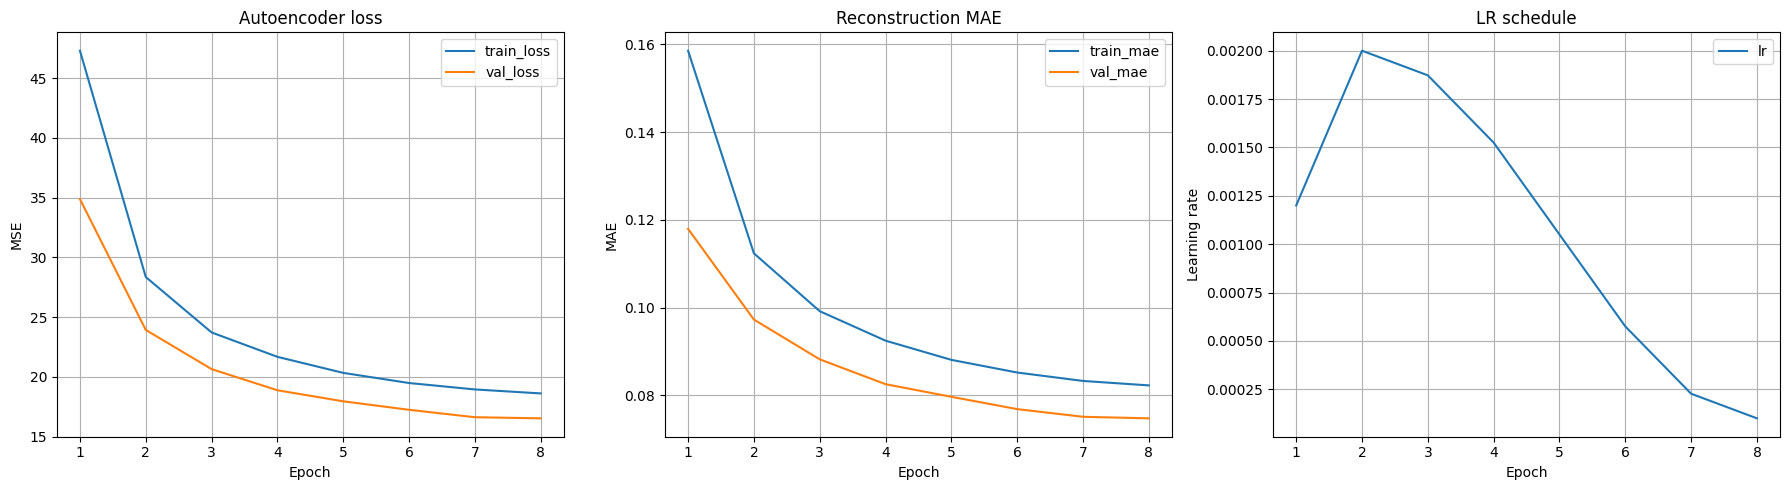


Best epoch: 8
Best val loss: 16.520752
Test loss (MSE): 15.881344
Test MAE: 0.073164


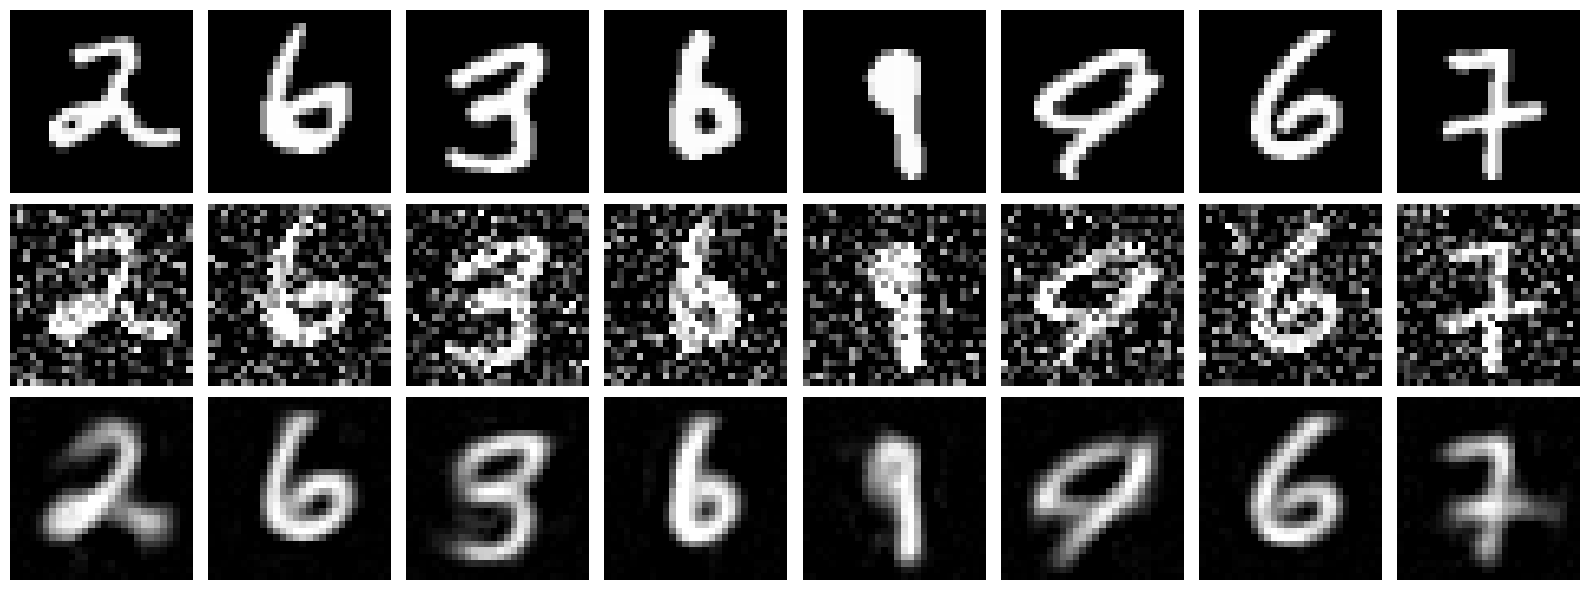

In [37]:

autoencoder = build_mnist_autoencoder(latent_dim=32, dropout_p=0.15, bn_alpha=0.9)
criterion_ae = MSECriterion()

optimizer_ae = AdamW(
    model=autoencoder,
    lr=0.002,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4,
)

history_ae, best_info_ae = train_autoencoder(
    model=autoencoder,
    criterion=criterion_ae,
    optimizer=optimizer_ae,
    train_loader=ae_train_loader,
    val_loader=ae_val_loader,
    epochs=8,
    noise_std=0.35,
    warmup_epochs=2,
    early_stopping_patience=4,
    min_delta=1e-4,
    verbose=True,
)

plot_autoencoder_history(history_ae)

test_stats_ae = evaluate_autoencoder(
    model=autoencoder,
    criterion=criterion_ae,
    data_loader=ae_test_loader,
    noise_std=0.35,
)

print("\nBest epoch:", best_info_ae["best_epoch"])
print(f"Best val loss: {best_info_ae['best_val_loss']:.6f}")
print(f"Test loss (MSE): {test_stats_ae['loss']:.6f}")
print(f"Test MAE: {test_stats_ae['mae']:.6f}")

show_autoencoder_reconstructions(
    model=autoencoder,
    data_loader=ae_test_loader,
    noise_std=0.35,
    n_images=8,
)


## Краткий вывод по автоэнкодеру

В этой части реализован **денойзинг-автоэнкодер для MNIST** на **собственных модулях**.

Что выполнено:
1. использованы **свёртки** и **max-pooling** в encoder-части;
2. использованы **полносвязные слои**;
3. добавлены **Dropout** и **BatchNormalization**;
4. в качестве функции потерь выбрана корректная для реконструкции величина — **MSE**;
5. добавлены **warmup**, **scheduler**, **early stopping** и сохранение лучшей модели;
6. проведена проверка на тесте и визуализирован результат реконструкции.

Отдельно был добавлен шум на вход, поэтому модель решает не просто задачу копирования, а именно задачу **восстановления изображения**, что делает эксперимент заметно более содержательным.


### __Реализую обычный автоэнкодер__


## Запуск обычного автоэнкодера

Ниже обучается уже **классический автоэнкодер**:
- на вход подаётся исходное изображение;
- на выходе модель должна восстановить это же изображение.

Таким образом, в ноутбуке теперь есть сразу два варианта:
1. **обычный автоэнкодер**;
2. **денойзинг-автоэнкодер**.

In [38]:

def evaluate_plain_autoencoder(model, criterion, data_loader):
    model.evaluate()

    total_loss = 0.0
    total_mae = 0.0
    total_count = 0

    for batch_x, _ in data_loader:
        x_clean = batch_x.numpy().astype(np.float32)
        x_clean = mnist_denormalize(x_clean)

        recon_flat = model.forward(x_clean)
        target_flat = x_clean.reshape(x_clean.shape[0], -1)

        loss = criterion.forward(recon_flat, target_flat)
        mae = mae_metric(target_flat, recon_flat)

        batch_size = x_clean.shape[0]
        total_loss += loss * batch_size
        total_mae += mae * batch_size
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "mae": total_mae / total_count,
    }


def train_plain_autoencoder(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    epochs=8,
    warmup_epochs=2,
    early_stopping_patience=4,
    min_delta=1e-4,
    verbose=True,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": [],
        "lr": [],
    }

    best_state = get_model_state(model)
    best_val_loss = float("inf")
    best_epoch = 0
    bad_epochs = 0

    steps_per_epoch = len(train_loader)

    dummy_param = torch.nn.Parameter(torch.tensor(0.0))
    scheduler_optimizer = torch.optim.SGD([dummy_param], lr=optimizer.lr)

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        scheduler_optimizer,
        start_factor=0.2,
        end_factor=1.0,
        total_iters=max(1, warmup_epochs * steps_per_epoch),
    )

    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        scheduler_optimizer,
        T_max=max(1, (epochs - warmup_epochs) * steps_per_epoch),
        eta_min=1e-4,
    )

    scheduler = torch.optim.lr_scheduler.SequentialLR(
        scheduler_optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[max(1, warmup_epochs * steps_per_epoch)],
    )

    for epoch in range(1, epochs + 1):
        print(f"Start epoch {epoch}/{epochs}")
        model.train()

        total_train_loss = 0.0
        total_train_mae = 0.0
        total_count = 0
        start_time = time.time()

        for batch_x, _ in train_loader:
            x_clean = batch_x.numpy().astype(np.float32)
            x_clean = mnist_denormalize(x_clean)

            target_flat = x_clean.reshape(x_clean.shape[0], -1)

            recon_flat = model.forward(x_clean)
            loss = criterion.forward(recon_flat, target_flat)

            grad_output = criterion.backward(recon_flat, target_flat)
            model.backward(x_clean, grad_output)

            optimizer.step()
            scheduler_optimizer.param_groups[0]["lr"] = optimizer.lr
            scheduler.step()
            optimizer.lr = scheduler_optimizer.param_groups[0]["lr"]

            mae = mae_metric(target_flat, recon_flat)

            batch_size = x_clean.shape[0]
            total_train_loss += loss * batch_size
            total_train_mae += mae * batch_size
            total_count += batch_size

        train_loss = total_train_loss / total_count
        train_mae = total_train_mae / total_count

        val_stats = evaluate_plain_autoencoder(model, criterion, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_stats["loss"])
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_stats["mae"])
        history["lr"].append(optimizer.lr)

        elapsed = time.time() - start_time

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.6f} | val_loss={val_stats['loss']:.6f} | "
                f"train_mae={train_mae:.6f} | val_mae={val_stats['mae']:.6f} | "
                f"lr={optimizer.lr:.6f} | time={elapsed:.1f}s"
            )

        if val_stats["loss"] < best_val_loss - min_delta:
            best_val_loss = val_stats["loss"]
            best_epoch = epoch
            best_state = get_model_state(model)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= early_stopping_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    load_model_state(model, best_state)

    best_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
    }

    return history, best_info


def show_plain_autoencoder_reconstructions(model, data_loader, n_images=8):
    model.evaluate()

    batch_x, _ = next(iter(data_loader))
    x_clean = batch_x[:n_images].numpy().astype(np.float32)
    x_clean = mnist_denormalize(x_clean)

    recon_flat = model.forward(x_clean)
    recon = recon_flat.reshape(-1, 1, 28, 28)
    recon = np.clip(recon, 0.0, 1.0)

    plt.figure(figsize=(2 * n_images, 4))

    for i in range(n_images):
        plt.subplot(2, n_images, i + 1)
        plt.imshow(x_clean[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Input", fontsize=12)

        plt.subplot(2, n_images, n_images + i + 1)
        plt.imshow(recon[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Recon", fontsize=12)

    plt.tight_layout()
    plt.show()


Start epoch 1/8
Epoch 01/8 | train_loss=38.313935 | val_loss=25.567376 | train_mae=0.133448 | val_mae=0.099450 | lr=0.006000 | time=38.3s
Start epoch 2/8
Epoch 02/8 | train_loss=24.529652 | val_loss=22.899877 | train_mae=0.098004 | val_mae=0.093704 | lr=0.002000 | time=36.4s
Start epoch 3/8
Epoch 03/8 | train_loss=20.736617 | val_loss=18.012001 | train_mae=0.086533 | val_mae=0.077845 | lr=0.001873 | time=36.0s
Start epoch 4/8
Epoch 04/8 | train_loss=19.486597 | val_loss=17.283038 | train_mae=0.082448 | val_mae=0.075680 | lr=0.001525 | time=36.4s
Start epoch 5/8
Epoch 05/8 | train_loss=18.841783 | val_loss=16.781623 | train_mae=0.080540 | val_mae=0.074116 | lr=0.001050 | time=36.2s
Start epoch 6/8
Epoch 06/8 | train_loss=18.264688 | val_loss=16.062037 | train_mae=0.078838 | val_mae=0.072404 | lr=0.000575 | time=34.5s
Start epoch 7/8
Epoch 07/8 | train_loss=17.939003 | val_loss=16.126034 | train_mae=0.077941 | val_mae=0.072117 | lr=0.000227 | time=37.8s
Start epoch 8/8
Epoch 08/8 | train

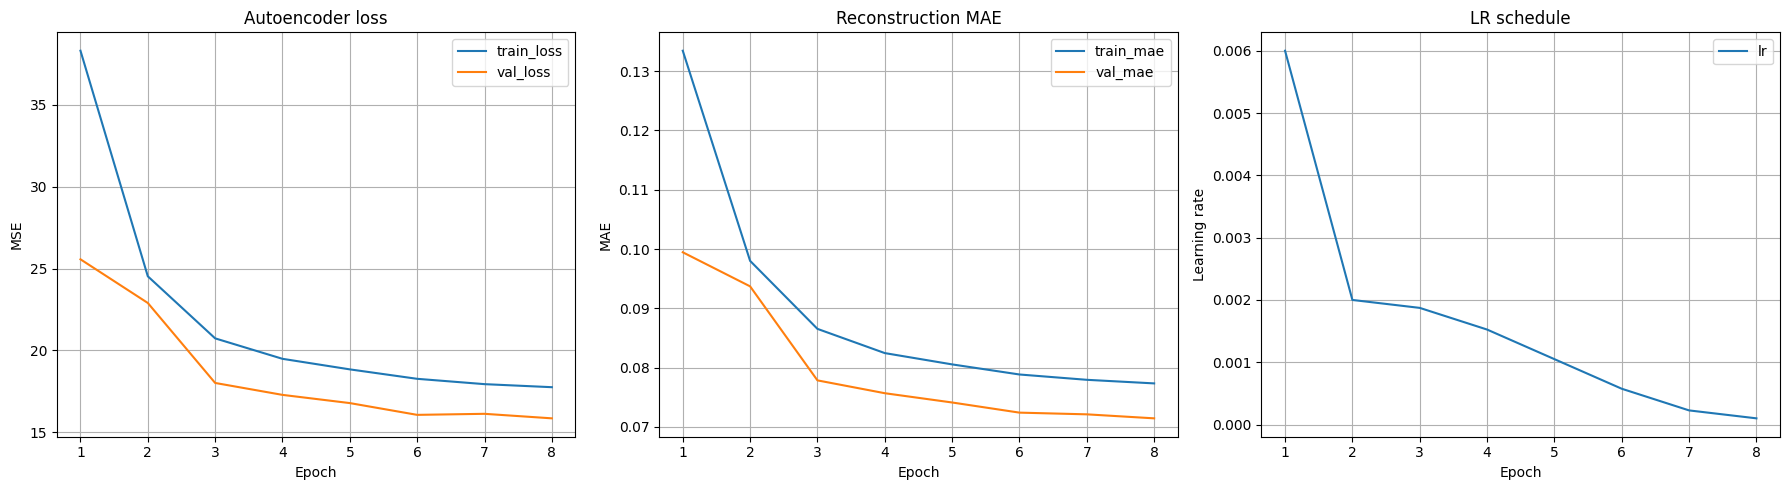


Best epoch: 8
Best val loss: 15.849491
Test loss (MSE): 15.157551
Test MAE: 0.069759


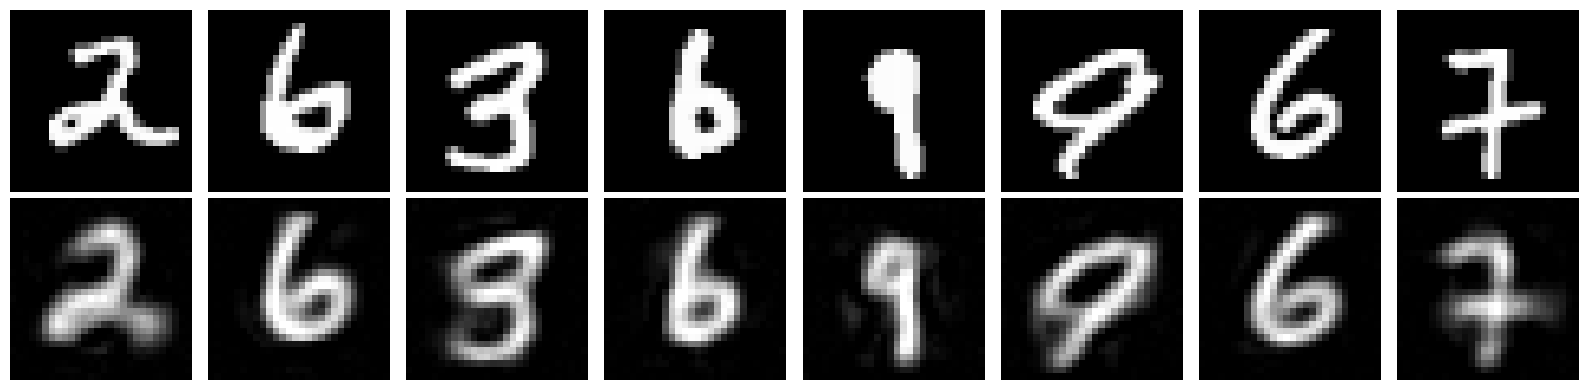

In [39]:

plain_autoencoder = build_mnist_autoencoder(latent_dim=32, dropout_p=0.15, bn_alpha=0.9)
criterion_plain_ae = MSECriterion()

optimizer_plain_ae = AdamW(
    model=plain_autoencoder,
    lr=0.002,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4,
)

history_plain_ae, best_info_plain_ae = train_plain_autoencoder(
    model=plain_autoencoder,
    criterion=criterion_plain_ae,
    optimizer=optimizer_plain_ae,
    train_loader=ae_train_loader,
    val_loader=ae_val_loader,
    epochs=8,
    warmup_epochs=2,
    early_stopping_patience=4,
    min_delta=1e-4,
    verbose=True,
)

plot_autoencoder_history(history_plain_ae)

test_stats_plain_ae = evaluate_plain_autoencoder(
    model=plain_autoencoder,
    criterion=criterion_plain_ae,
    data_loader=ae_test_loader,
)

print("\nBest epoch:", best_info_plain_ae["best_epoch"])
print(f"Best val loss: {best_info_plain_ae['best_val_loss']:.6f}")
print(f"Test loss (MSE): {test_stats_plain_ae['loss']:.6f}")
print(f"Test MAE: {test_stats_plain_ae['mae']:.6f}")

show_plain_autoencoder_reconstructions(
    model=plain_autoencoder,
    data_loader=ae_test_loader,
    n_images=8,
)


## Краткий вывод по обычному автоэнкодеру

Дополнительно к денойзинг-варианту был реализован и **обычный автоэнкодер** для MNIST.  
В нём модель получает на вход исходное изображение и обучается восстанавливать его же.

Таким образом, в ноутбуке представлены сразу две корректные реализации (на всякий случай, мало ли):
- **классический автоэнкодер**;
- **денойзинг-автоэнкодер**.